<a href="https://colab.research.google.com/github/marioguerrerosalah/APRENDIZAJE--SUPERVISADO/blob/main/Parcial_1_MARIO_GUERRERO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parcial 1: Regresión múltiple y regularización

Entregables:
*   Notebook / script con el código y resultados.
*   Informe ejecutivo (enfocado en conclusiones para la toma de decisiones de negocio).


Una empresa de consultoría en gestión del talento humano desea entender los factores que más influyen en los salarios de los trabajadores (wage). Para esto, cuenta con el dataset wage_dataset, que incluye variables demográficas, educativas y laborales de los individuos.

El objetivo es explicar el salario a partir de las demás variables.

Se debe comparar diferentes métodos de regresión para obtener un modelo más robusto y útil para la toma de decisiones.


## Análisis exploratorio inicial:
- Describa las principales variables del dataset.
- Detecte correlaciones altas, posibles multicolinealidades y valores atípicos.

## Regresión múltiple clásica (OLS):
- Estime un modelo de regresión múltiple para explicar el salario (wage).
- Evalúe la significancia de las variables y la bondad de ajuste.

## Modelos de regresión con regularización:
- Estime un modelo con Ridge y otro con Lasso.
- Use validación cruzada para seleccionar el parámetro de penalización (α o λ).

## Comparación de desempeño:
- Compare OLS, Ridge y Lasso en términos de R², RMSE y MAE.
- Analice si los modelos con regularización mejoran el desempeño predictivo frente a la regresión clásica.

## Variables relevantes:
- Identifique las variables más influyentes en cada modelo.
- Comente si hay diferencias entre OLS y Lasso (que hace selección de variables).

## Diagnóstico de problemas:
- Evalúe si existen problemas de multicolinealidad, heterocedasticidad o sobreajuste.
- Explique cómo la regularización ayuda a mitigar algunos de estos problemas.

# Informe ejecutivo (para directivos de la empresa)
- Redacte un informe breve que incluya:


## Hallazgos principales:
- Variables que más impactan los salarios.
- Diferencias entre modelos OLS y los modelos con regularización.

## Implicaciones para la gestión del talento humano:
- ¿Qué factores deberían priorizarse para explicar diferencias salariales?
- ¿Qué riesgos existen si se ignoran problemas estadísticos como multicolinealidad?

## Recomendaciones:
- Estrategias para la política salarial.



1. conexion a drive y librerias

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns


2. Importamos archivo CSV

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/APREN. SUPERVISADO/Dataset.csv', encoding="latin1")
df.head()

,age,education,experience,jobclass,region,salary
0,56,SomeCollege,9,Industrial,South,76496
1,46,SomeCollege,20,Information,West,60938
2,32,HS,19,Information,West,25206
3,60,Advanced,7,Information,East,57042
4,25,College,35,Industrial,East,27456


3. Analisis exploratorio inicial

In [ ]:
print(df['region'].unique())
print(df['jobclass'].unique())
print(df['education'].unique())

['SomeCollege' 'HS' 'Advanced' 'College' '<HS']


In [ ]:
## Vamos a convertir la variable jobclass a 0 Y 1
df['jobclass'] = df['jobclass'].replace({'Industrial': 0, 'Information': 1})
df.head()

/tmp/ipykernel_711/2348820236.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['jobclass'] = df['jobclass'].replace({'Industrial': 0, 'Information': 1})


,age,education,experience,jobclass,region,salary
0,56,SomeCollege,9,0,South,76496
1,46,SomeCollege,20,1,West,60938
2,32,HS,19,1,West,25206
3,60,Advanced,7,1,East,57042
4,25,College,35,0,East,27456


In [ ]:
## Convertimos Region a numerica tambien
# df = pd.get_dummies(df, columns=['region'], prefix='region', drop_first=False)
boolean_cols = ['region_South', 'region_West', 'region_East']
df[boolean_cols] = df[boolean_cols].astype(int)
df.head()

,age,experience,jobclass,salary,region_East,region_South,region_West,education_<HS,education_Advanced,education_College,education_HS,education_SomeCollege
0,56,9,0,76496,0,1,0,0,0,0,0,1
1,46,20,1,60938,0,0,1,0,0,0,0,1
2,32,19,1,25206,0,0,1,0,0,0,1,0
3,60,7,1,57042,1,0,0,0,1,0,0,0
4,25,35,0,27456,1,0,0,0,0,1,0,0


In [ ]:
# df = pd.get_dummies(df, columns=['education'], prefix='education', drop_first=False)
boolean_cols = ['education_SomeCollege', 'education_College', 'education_Advanced', 'education_HS', 'education_<HS']
df[boolean_cols] = df[boolean_cols].astype(int)
df.head()

,age,experience,jobclass,salary,region_East,region_South,region_West,education_<HS,education_Advanced,education_College,education_HS,education_SomeCollege
0,56,9,0,76496,0,1,0,0,0,0,0,1
1,46,20,1,60938,0,0,1,0,0,0,0,1
2,32,19,1,25206,0,0,1,0,0,0,1,0
3,60,7,1,57042,1,0,0,0,1,0,0,0
4,25,35,0,27456,1,0,0,0,0,1,0,0


In [ ]:
# Para ver los valores vacíos en cada columna
print("Valores nulos antes de la eliminación:")
print(df.isnull().sum())

# Para eliminar las filas con valores vacíos
df_cleaned = df.dropna()

print("\nValores nulos después de la eliminación:")
print(df_cleaned.isnull().sum())
print(f"\nDimensiones del DataFrame original: {df.shape}")
print(f"Dimensiones del DataFrame después de eliminar nulos: {df_cleaned.shape}")

Valores nulos antes de la eliminación:
age                      0
experience               0
jobclass                 0
salary                   0
region_East              0
region_South             0
region_West              0
education_<HS            0
education_Advanced       0
education_College        0
education_HS             0
education_SomeCollege    0
dtype: int64

Valores nulos después de la eliminación:
age                      0
experience               0
jobclass                 0
salary                   0
region_East              0
region_South             0
region_West              0
education_<HS            0
education_Advanced       0
education_College        0
education_HS             0
education_SomeCollege    0
dtype: int64

Dimensiones del DataFrame original: (3000, 12)
Dimensiones del DataFrame después de eliminar nulos: (3000, 12)


Matriz de correlacion

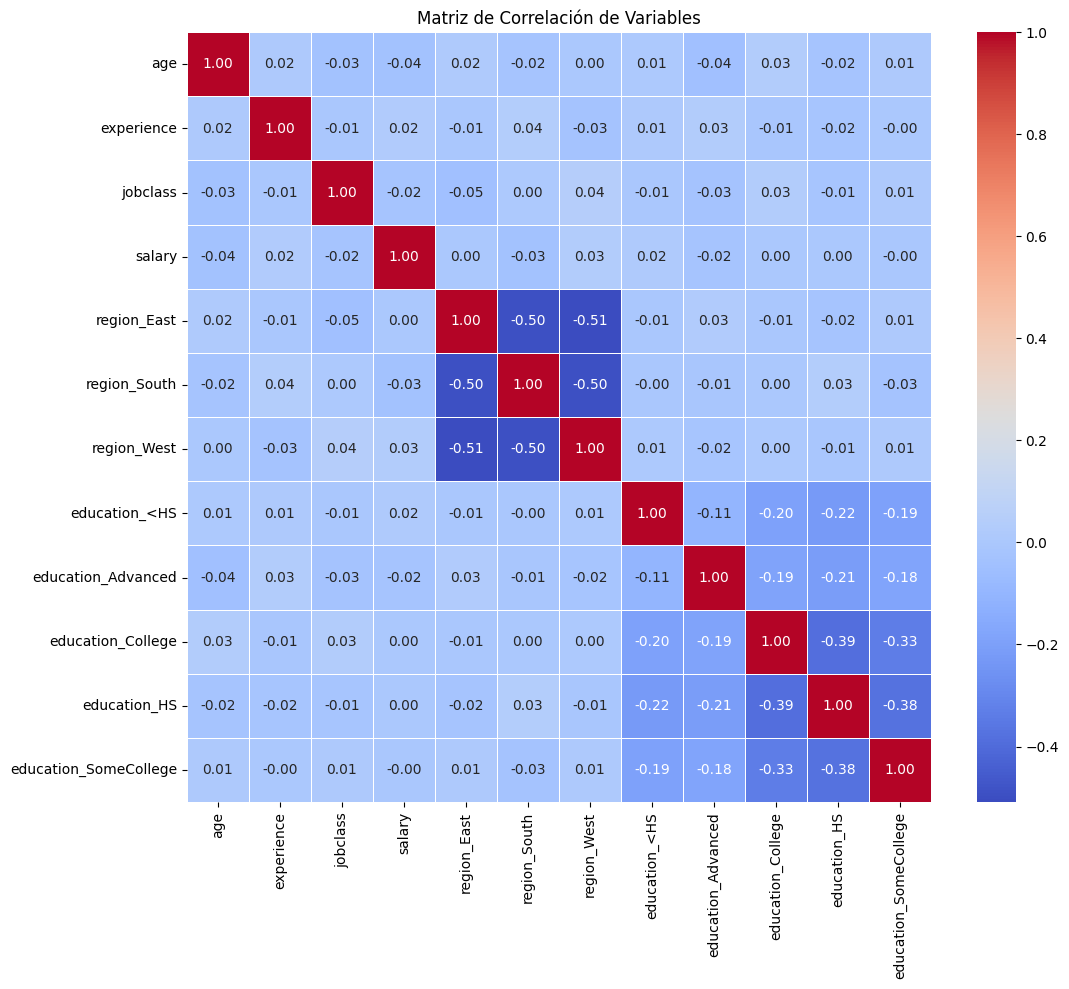

In [ ]:
correlation_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables')
plt.show()

# **ANALISIS MATRIZ DE CORREALCION**

La matriz de correlación muestra que la variable salary no presenta correlaciones lineales fuertes con las demás variables del dataset, ya que la mayoría de los coeficientes están muy cerca de cero. Esto sugiere que el salario no depende de un solo factor de manera aislada, sino posiblemente de la combinación de varias variables al mismo tiempo, lo cual justifica el uso de un modelo de regresión múltiple. Por otro lado, se observan correlaciones negativas moderadas entre las variables de región (region_East, region_South y region_West) y entre los distintos niveles educativos, lo cual es esperado porque estas variables fueron transformadas en variables dummy a partir de categorías originales mutuamente excluyentes. En general, no se observan problemas evidentes de correlaciones extremadamente altas entre variables independientes, aunque será importante evaluar posteriormente la posible multicolinealidad con métricas adicionales dentro del modelo de regresión.

4. Regresión múltiple clásica (OLS):
- Estime un modelo de regresión múltiple para explicar el salario (wage).
- Evalúe la significancia de las variables y la bondad de ajuste.

In [ ]:
Y = df["salary"]              # Variable dependiente
X = df.drop("salary", axis=1) # Variables independientes

In [ ]:
# Intercepto
X_const = sm.add_constant(X)

# Debug: Print shapes to identify mismatch
print(f"Shape of Y: {Y.shape}")
print(f"Shape of X: {X.shape}")
print(f"Shape of X_const: {X_const.shape}")

# Modelo de regresión
modelo_sm = sm.OLS(Y, X_const).fit()

# Imprimir el resumen del modelo (incluye la ecuación y ANOVA)
print(modelo_sm.summary())

# Obtener y mostrar los residuales
residuales = modelo_sm.resid
print("\nResiduales:")
print(residuales)

Shape of Y: (3000,)
Shape of X: (3000, 11)
Shape of X_const: (3000, 12)
                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.548
Date:                Thu, 12 Mar 2026   Prob (F-statistic):              0.125
Time:                        15:06:43   Log-Likelihood:                -33136.
No. Observations:                3000   AIC:                         6.629e+04
Df Residuals:                    2990   BIC:                         6.635e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------

# **ANALISIS DE MODELO DE REGRESION CLASICO**

El modelo de regresión múltiple estimado mediante OLS muestra un R² de 0.005, lo que indica que las variables incluidas explican una proporción muy baja de la variabilidad del salario. Esto sugiere que existen otros factores no observados que podrían estar influyendo en la determinación de los salarios. En términos de significancia estadística, las variables relacionadas con la región y el nivel educativo resultan altamente significativas (p-value < 0.05), lo que indica que estas características tienen una relación importante con el salario. En contraste, variables como la experiencia y la clase de trabajo no resultaron estadísticamente significativas dentro del modelo. Además, el alto número de condición sugiere la posible presencia de multicolinealidad, probablemente asociada a la inclusión de múltiples variables dummy derivadas de una misma categoría.

5. Modelos de regresión con regularización:
- Estime un modelo con Ridge y otro con Lasso.
- Use validación cruzada para seleccionar el parámetro de penalización (α o λ).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
y = df["salary"]
X = df.drop("salary", axis=1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
## MODELO OLS (PARA COMPARAR)
X_train_ols = sm.add_constant(X_train)
X_test_ols = sm.add_constant(X_test)

modelo_ols = sm.OLS(y_train, X_train_ols).fit()

pred_ols = modelo_ols.predict(X_test_ols)

In [ ]:
#MODELO RIDGE
alphas = np.logspace(-3,3,100)

ridge = RidgeCV(alphas=alphas, cv=5)

ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

print("Mejor alpha Ridge:", ridge.alpha_)


Mejor alpha Ridge: 1000.0


In [ ]:
##MODELO LASSO
lasso = LassoCV(alphas=alphas, cv=5, max_iter=10000)

lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)

print("Mejor alpha Lasso:", lasso.alpha_)

Mejor alpha Lasso: 1000.0


In [ ]:
def metricas(y_real, y_pred):

    r2 = r2_score(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)

    return r2, rmse, mae


r2_ols, rmse_ols, mae_ols = metricas(y_test, pred_ols)
r2_ridge, rmse_ridge, mae_ridge = metricas(y_test, ridge_pred)
r2_lasso, rmse_lasso, mae_lasso = metricas(y_test, lasso_pred)


In [ ]:
resultados = pd.DataFrame({

    "Modelo": ["OLS","Ridge","Lasso"],

    "R2":[r2_ols,r2_ridge,r2_lasso],

    "RMSE":[rmse_ols,rmse_ridge,rmse_lasso],

    "MAE":[mae_ols,mae_ridge,mae_lasso]

})

print(resultados)

coef_ridge = pd.Series(ridge.coef_, index=X.columns)
coef_lasso = pd.Series(lasso.coef_, index=X.columns)

print("\nCoeficientes Ridge:")
print(coef_ridge.sort_values(ascending=False))

print("\nCoeficientes Lasso:")
print(coef_lasso.sort_values(ascending=False))

  Modelo        R2          RMSE           MAE
0    OLS -0.009124  14909.645500  11901.899979
1  Ridge -0.007440  14897.205527  11902.779324
2  Lasso -0.004929  14878.622457  11909.898007

Coeficientes Ridge:
region_West              373.994864
experience               271.954324
education_<HS            210.536739
education_College         64.585396
education_HS             -48.694397
education_SomeCollege    -66.892615
region_East              -84.699451
jobclass                 -85.613801
education_Advanced      -140.535819
region_South            -291.319815
age                     -482.799444
dtype: float64

Coeficientes Lasso:
age                     -0.0
experience               0.0
jobclass                -0.0
region_East             -0.0
region_South            -0.0
region_West              0.0
education_<HS            0.0
education_Advanced      -0.0
education_College        0.0
education_HS            -0.0
education_SomeCollege   -0.0
dtype: float64


6. diagnóstico de problemas:

Evalúe si existen problemas de multicolinealidad, heterocedasticidad o sobreajuste.

In [ ]:
df.columns

Index(['age', 'experience', 'jobclass', 'salary', 'region_East',
       'region_South', 'region_West', 'education_<HS', 'education_Advanced',
       'education_College', 'education_HS', 'education_SomeCollege'],
      dtype='object')

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Definir las variables independientes
X_vif = df[['age', 'experience', 'jobclass', 'region_East',
       'region_South', 'region_West', 'education_<HS', 'education_Advanced',
       'education_College', 'education_HS', 'education_SomeCollege']]

# Calcular el VIF para cada variable
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print(vif_data)

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                  feature       VIF
0                     age  1.005112
1              experience  1.003152
2                jobclass  1.005754
3             region_East       inf
4            region_South       inf
5             region_West       inf
6           education_<HS       inf
7      education_Advanced       inf
8       education_College       inf
9            education_HS       inf
10  education_SomeCollege       inf


# **El análisis del VIF (Variance Inflation Factor)**

 muestra que las variables age, experience y jobclass tienen valores cercanos a 1, lo que indica que no presentan problemas de multicolinealidad. Sin embargo, las variables relacionadas con región (region_East, region_South, region_West) y nivel educativo (education_<HS, education_Advanced, education_College, education_HS, education_SomeCollege) presentan valores de VIF infinitos, lo que indica la presencia de multicolinealidad perfecta. Esto ocurre porque estas variables fueron codificadas como variables dummy incluyendo todas las categorías posibles, lo que genera dependencia lineal entre ellas. En este contexto, los modelos de regularización como Ridge y Lasso ayudan a mitigar este problema, ya que penalizan el tamaño de los coeficientes y permiten reducir la inestabilidad que genera la multicolinealidad en la regresión clásica OLS.

# **Informe Ejecutivo – Determinantes del salario**

- **Hallazgos principales**

El análisis realizado buscó identificar qué factores influyen en el salario de los trabajadores a partir de variables demográficas, educativas y laborales. Los resultados muestran que algunas variables relacionadas con la región geográfica y el nivel educativo presentan mayor influencia relativa dentro de los modelos de regresión. Sin embargo, en términos generales, los modelos presentan una capacidad explicativa baja, lo que sugiere que las variables incluidas en el dataset no capturan completamente los factores que determinan las diferencias salariales. Al comparar los modelos, la regresión clásica OLS y los modelos con regularización (Ridge y Lasso) presentan un desempeño predictivo muy similar. En particular, el modelo Lasso elimina la mayoría de las variables al reducir sus coeficientes a cero, lo que indica que ninguna variable tiene un impacto suficientemente fuerte para explicar el salario por sí sola.

- **Implicaciones para la gestión del talento humano**

Desde la perspectiva de gestión del talento humano, los resultados sugieren que factores como el nivel educativo y la ubicación regional podrían tener cierta relación con las diferencias salariales entre empleados. No obstante, el bajo poder explicativo del modelo indica que existen otros factores relevantes que no están siendo considerados, como habilidades específicas, desempeño laboral, tipo de industria o responsabilidades dentro de la organización. Además, ignorar problemas estadísticos como la multicolinealidad puede generar interpretaciones erróneas sobre la importancia de ciertas variables, lo que podría llevar a tomar decisiones salariales basadas en relaciones poco confiables o inestables.

- **Recomendaciones**

Se recomienda que la empresa complemente el análisis salarial incorporando variables adicionales que reflejen mejor las características del puesto y del desempeño del trabajador. Asimismo, es importante utilizar metodologías analíticas que permitan identificar de forma más precisa los factores que realmente influyen en la compensación. Desde una perspectiva de política salarial, la organización debería considerar estrategias que integren tanto el nivel de formación como las condiciones del mercado laboral regional, pero también incluir criterios relacionados con productividad, habilidades y responsabilidades del cargo, con el fin de diseñar estructuras salariales más justas, competitivas y basadas en evidencia.